#Effect of Missing Data on Random Forest Performance

## Introduction

Previous experiments investigated the effect of missing data on Logistic Regression and Decision Tree classifiers.

However, ensemble learning algorithms such as Random Forest may respond differently to incomplete datasets because they combine predictions from multiple decision trees.

The objective of this experiment is to investigate how different levels of missing data affect the performance of a Random Forest classifier using the Titanic dataset.

## Import Libraries

The following libraries are required for data preprocessing, model training, evaluation, and visualization.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

import matplotlib.pyplot as plt

## Load Dataset

The Titanic dataset is loaded into a pandas DataFrame and will be used throughout the experiment.

In [7]:
df = pd.read_csv("Titanic-Dataset.csv")

## Data Preparation

Before introducing missing values, the dataset is preprocessed.

Categorical variables are converted into numerical values using one-hot encoding, and unnecessary columns are removed.

The Age column is intentionally left unchanged because missing values will be introduced and handled during the experiment.

In [8]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = pd.get_dummies(df,columns=["Sex", "Embarked"],drop_first=True)

df = df.drop(columns=[ "PassengerId", "Name","Ticket","Cabin"])

## Create Evaluation Function

A function is created to simulate different levels of missing data, preprocess the dataset, train a Random Forest classifier, and evaluate its performance.

Using a function ensures that each experiment is performed under identical conditions.

In [10]:
def evaluate_missing_data(df, missing_fraction):

    data = df.copy()

    missing_indexes = data.sample(frac=missing_fraction,random_state=42).index

    data.loc[ missing_indexes, "Age"] = np.nan

    data["Age"] = data["Age"].fillna(data["Age"].median())

    X = data.drop(columns=["Survived"])
    y = data["Survived"]

    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42)

    model = RandomForestClassifier( n_estimators=100,random_state=42)

    model.fit( X_train, y_train)

    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix( y_test, y_pred ).ravel()

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp}

## Evaluate Different Missing Data Levels

The Random Forest classifier is evaluated using four versions of the dataset containing 0%, 10%, 20%, and 30% missing values.

The results are collected for comparison.

In [11]:
results = []

missing_levels = [0, 0.1, 0.2, 0.3]

for level in missing_levels:

    result = evaluate_missing_data(df,level)

    result["Missing Data"] = f"{int(level*100)}%"

    results.append(result)

## Create Comparison Table

The evaluation results are converted into a pandas DataFrame for comparison across different levels of missing data.

In [12]:
comparison = pd.DataFrame(results)

comparison = comparison[["Missing Data", "Accuracy", "Precision", "Recall", "F1-score", "True Negative", "False Positive", "False Negative", "True Positive"]]

comparison = comparison.round(3)

comparison

,Missing Data,Accuracy,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive
0,0%,0.821,0.800,0.757,0.778,91,14,18,56
1,10%,0.799,0.757,0.757,0.757,87,18,18,56
2,20%,0.782,0.733,0.743,0.738,85,20,19,55
3,30%,0.782,0.754,0.703,0.727,88,17,22,52


## Analysis of Results

The experiment demonstrates that missing data negatively affects the performance of the Random Forest classifier.

The highest performance was achieved using the complete dataset without missing values. The model obtained an Accuracy of 0.821 and an F1-score of 0.778.

As the proportion of missing data increased, the overall performance gradually declined. Accuracy decreased from 0.821 to 0.782, while the F1-score dropped from 0.778 to 0.727.

The confusion matrix also reflects this trend. The number of correctly classified positive cases (True Positives) decreased from 56 to 52, while False Negatives increased from 18 to 22 when 30% missing values were introduced.

Although the decline was moderate, the results indicate that missing data still reduces the predictive performance of the Random Forest classifier. However, the model remained relatively stable compared with the previous algorithms.

## Conclusion

This experiment investigated the influence of missing data on the performance of a Random Forest classifier.

Unlike the Decision Tree experiment, Random Forest achieved its best performance using the complete dataset without missing values. Increasing the percentage of missing data gradually reduced Accuracy, Recall, and F1-score.

Despite this decline, the performance degradation was relatively small, indicating that Random Forest is robust to moderate levels of missing data. Overall, the experiment suggests that Random Forest is one of the most stable classifiers when working with incomplete datasets.

## Accuracy Comparison

The following graph illustrates how different levels of missing data influence the Accuracy of the Random Forest classifier.

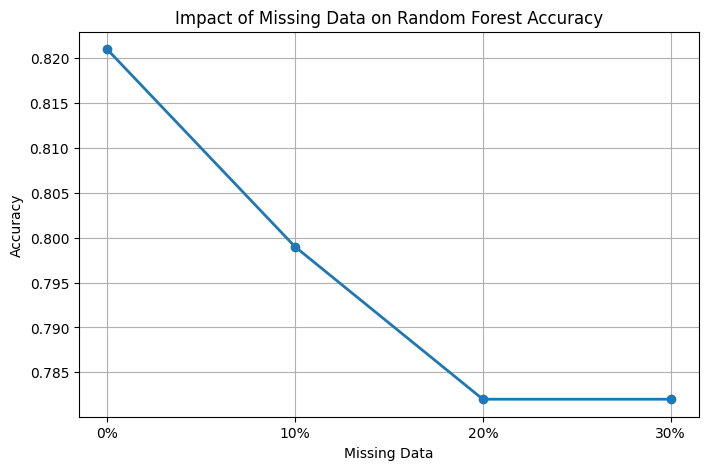

In [16]:
plt.figure(figsize=(8,5))

plt.plot(comparison["Missing Data"], comparison["Accuracy"],marker="o",linewidth=2)

plt.xlabel("Missing Data")
plt.ylabel("Accuracy")
plt.title("Impact of Missing Data on Random Forest Accuracy")

plt.grid(True)

plt.savefig("random_forest_missing_accuracy.png")

plt.show()

## F1-score Comparison

The following graph illustrates how different levels of missing data influence the F1-score of the Random Forest classifier.

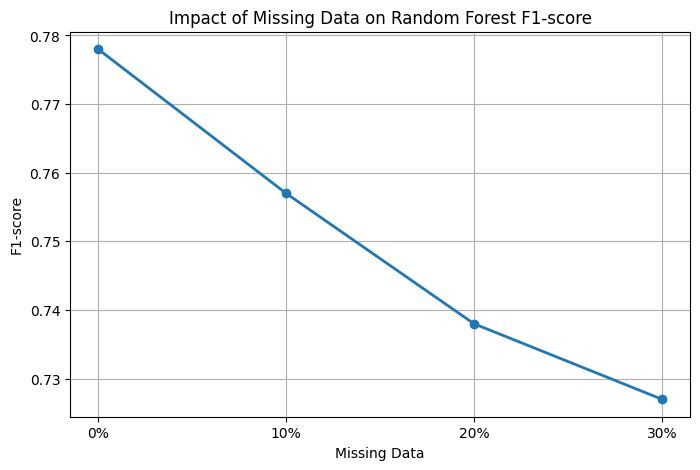

In [17]:
plt.figure(figsize=(8,5))

plt.plot(comparison["Missing Data"],comparison["F1-score"],marker="o",linewidth=2)

plt.xlabel("Missing Data")
plt.ylabel("F1-score")
plt.title("Impact of Missing Data on Random Forest F1-score")

plt.grid(True)

plt.savefig("random_forest_missing_f1.png")

plt.show()